<a href="https://colab.research.google.com/github/gmanthenoxus/Data_Driven_Capacity_Planning_for_UK_Data_Centres/blob/main/Data_Driven_Capacity_Planning_for_UK_Data_Centres.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook: Data-Driven Capacity Planning for UK Data Centres**

**Author:** Moses Mana Gana

**Project:** A Data Driven Approach to Capacity Planning in UK Data Centres Using Predictive Modelling

**Environment:** Google Colab

## 1 Setup and Library Imports

In [1]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost statsmodels tensorflow plotly

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import gzip
import tarfile
import warnings
import xgboost as xgb
import plotly.graph_objects as go
import tensorflow as tf
warnings.filterwarnings("ignore", category=UserWarning)

from datetime import datetime, timedelta
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from google.colab import files
from plotly.subplots import make_subplots
from IPython.display import display, clear_output
from google.colab import output

print("All libraries imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 124.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 848.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 111.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 1.3 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
All libraries imported successfully.


## 2 Data Acquisition

### 2.1 Alibaba 2018 Trace

In [2]:
# Alibaba 2018 Trace

# Column names for machine_usage.csv
cols = ['machine_id', 'timestamp', 'cpu_util_percent', 'mem_util_percent',
        'mem_gps', 'mkpi', 'net_in', 'net_out', 'disk_io_percent']

# Download the public file
!wget -O machine_usage.tar.gz "http://aliopentrace.oss-cn-beijing.aliyuncs.com/v2018Traces/machine_usage.tar.gz"

# Process in chunks, aggregate to 5-minute bins per machine
agg_list = []
with tarfile.open('machine_usage.tar.gz', 'r:gz') as tar:
    f = tar.extractfile('machine_usage.csv')
    chunk_iter = pd.read_csv(f, names=cols, chunksize=500000)
    for chunk in chunk_iter:
        chunk['time_bin'] = (chunk['timestamp'] // 300) * 300
        agg = chunk.groupby(['machine_id', 'time_bin']).agg({
            'cpu_util_percent': 'mean',
            'mem_util_percent': 'mean',
            'net_in': 'mean',
            'net_out': 'mean',
            'disk_io_percent': 'mean'
        }).reset_index()
        agg_list.append(agg)

# Combine all chunks
df_alibaba = pd.concat(agg_list, ignore_index=True)

# Critical fix**: collapse any duplicate (machine, time_bin) pairs across chunks
df_alibaba = df_alibaba.groupby(['machine_id', 'time_bin']).agg({
    'cpu_util_percent': 'mean',
    'mem_util_percent': 'mean',
    'net_in': 'mean',
    'net_out': 'mean',
    'disk_io_percent': 'mean'
}).reset_index()

# Keep only first 8 days
df_alibaba = df_alibaba[df_alibaba['time_bin'] <= 8*86400]
print(f"Alibaba final shape: {df_alibaba.shape}")

# Validation check for a single machine
single_machine = 'm_1932'
test = df_alibaba[df_alibaba['machine_id'] == single_machine]
unique_bins = test['time_bin'].nunique()
print(f"Unique time bins for machine {single_machine}: {unique_bins}")
print(f"Expected ~2304. Missing bins: {2304 - unique_bins}")

--2026-04-14 14:58:46--  http://aliopentrace.oss-cn-beijing.aliyuncs.com/v2018Traces/machine_usage.tar.gz
Resolving aliopentrace.oss-cn-beijing.aliyuncs.com (aliopentrace.oss-cn-beijing.aliyuncs.com)... 39.107.23.78
Connecting to aliopentrace.oss-cn-beijing.aliyuncs.com (aliopentrace.oss-cn-beijing.aliyuncs.com)|39.107.23.78|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1774523160 (1.7G) [application/gzip]
Saving to: ‘machine_usage.tar.gz’

machine_usage.tar.g 100%[===================>]   1.65G  16.8MB/s    in 91s     

2026-04-14 15:00:18 (18.6 MB/s) - ‘machine_usage.tar.gz’ saved [1774523160/1774523160]

Alibaba final shape: (8389672, 7)
Unique time bins for machine m_1932: 2095
Expected ~2304. Missing bins: 209


### 2.2 Google 2019 Trace

In [3]:
# Download the JSON shard
!gsutil cp gs://clusterdata_2019_a/instance_usage-000000000000.json.gz .

# Parse the entire file
records = []
with gzip.open('instance_usage-000000000000.json.gz', 'rt') as f:
    for line in f:
        rec = json.loads(line)
        start_us = rec.get('start_time')
        if start_us is None:
            continue
        avg_usage = rec.get('average_usage', {})
        cpu = avg_usage.get('cpus')
        if cpu is None:
            continue
        machine_id = rec.get('machine_id')
        records.append({
            'start_time_s': int(start_us) / 1_000_000,
            'cpu_avg': float(cpu),
            'machine_id': str(machine_id)
        })

df_google = pd.DataFrame(records)
print(f"Google raw shape: {df_google.shape}")

# Filter to first 8 days
df_google = df_google[df_google['start_time_s'] <= 8*86400]
print(f"After 8-day filter: {df_google.shape}")

# Create 5-minute bins
df_google['time_bin'] = (df_google['start_time_s'] // 300) * 300

# Optional: choose the most active machine for single-machine series
machine_counts = df_google['machine_id'].value_counts()
top_machine = machine_counts.index[0]
print(f"Most active machine: {top_machine} with {machine_counts.iloc[0]} records")

# Single machine series
df_google_single = df_google[df_google['machine_id'] == top_machine].copy()
df_google_single = df_google_single.groupby('time_bin')['cpu_avg'].mean().reset_index()
print(f"Google single machine shape: {df_google_single.shape}")

# Cluster average
df_google_avg = df_google.groupby('time_bin')['cpu_avg'].mean().reset_index()
print(f"Google cluster average shape: {df_google_avg.shape}")

# Validation: number of unique time bins
unique_bins_google = df_google_avg['time_bin'].nunique()
print(f"Unique time bins in Google cluster average: {unique_bins_google} (expected ~2304)")

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://clusterdata_2019_a/instance_usage-000000000000.json.gz...
==> NOTE: You are downloading one or more large file(s), which would
run significantly faster if you enabled sliced object downloads. This
feature is enabled by default but requires that compiled crcmod be
installed (see "gsutil help crcmod").

/ [1 files][475.3 MiB/475.3 MiB]                                                
Operation completed over 1 objects/475.3 MiB.                                    
Google raw shape: (4000943, 3)
After 8-day filter: (757233, 3)
Most active machine: 375997572163 with 3580 records
Google single machine shape: (698, 2)
Google cluster average shape: (2304, 2)
Unique time bins in Google cluster average: 2304 (expected ~2304)


### 2.3 Azure V2 Trace

In [4]:
# Download first 60 CPU readings files
base_url = "https://azurepublicdatasettraces.blob.core.windows.net/azurepublicdatasetv2/trace_data/vm_cpu_readings/vm_cpu_readings-file-{}-of-195.csv.gz"
all_azure = []
for i in range(1, 61):
    url = base_url.format(i)
    local_file = f"azure_{i}.csv.gz"
    !wget -O {local_file} {url}
    # Read only timestamp and avg CPU
    df = pd.read_csv(local_file, compression='gzip', names=['ts','vm','min','max','avg'], usecols=['ts','avg'])
    df['time_bin'] = (df['ts'] // 300) * 300
    df_bin = df.groupby('time_bin')['avg'].mean().reset_index()
    all_azure.append(df_bin)
    !rm {local_file}  # remove to save space
    if i % 10 == 0:
        print(f"Processed {i} files")

df_azure = pd.concat(all_azure, ignore_index=True)
df_azure = df_azure[df_azure['time_bin'] <= 8*86400]
print(f"Azure combined shape: {df_azure.shape}")

# For Azure, we treat each 'time_bin' as a single time series
df_azure_single = df_azure.copy()
df_azure_avg = df_azure.copy()

--2026-04-14 15:04:01--  https://azurepublicdatasettraces.blob.core.windows.net/azurepublicdatasetv2/trace_data/vm_cpu_readings/vm_cpu_readings-file-1-of-195.csv.gz
Resolving azurepublicdatasettraces.blob.core.windows.net (azurepublicdatasettraces.blob.core.windows.net)... 52.239.236.228
Connecting to azurepublicdatasettraces.blob.core.windows.net (azurepublicdatasettraces.blob.core.windows.net)|52.239.236.228|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 856259637 (817M) [application/octet-stream]
Saving to: ‘azure_1.csv.gz’

azure_1.csv.gz      100%[===================>] 816.59M  53.0MB/s    in 20s     

2026-04-14 15:04:22 (40.5 MB/s) - ‘azure_1.csv.gz’ saved [856259637/856259637]

--2026-04-14 15:04:34--  https://azurepublicdatasettraces.blob.core.windows.net/azurepublicdatasetv2/trace_data/vm_cpu_readings/vm_cpu_readings-file-2-of-195.csv.gz
Resolving azurepublicdatasettraces.blob.core.windows.net (azurepublicdatasettraces.blob.core.windows.net)... 52.2

In [9]:
# Trim to first 8 days
df_azure = df_azure[df_azure['time_bin'] <= 8*86400]
print(f"Azure trimmed shape: {df_azure.shape}")

# Rename column for consistency
if 'avg' in df_azure.columns:
    df_azure.rename(columns={'avg': 'cpu_avg'}, inplace=True)

# Validation: number of unique time bins
unique_bins_azure = df_azure['time_bin'].nunique()
print(f"Unique time bins in Azure: {unique_bins_azure} (expected ~2304)")

Azure trimmed shape: (2356, 2)
Unique time bins in Azure: 2305 (expected ~2304)


### 2.4 Synthetic UK Data and UK Power Networks Validation

In [5]:
# Generate synthetic UK workload

start_date = datetime(2023, 1, 1)
end_date = start_date + timedelta(days=8)
date_range = pd.date_range(start=start_date, end=end_date, freq='5T', inclusive='left')

# Daily pattern
hour = date_range.hour
daily_factor = 0.5 + 0.5 * np.sin(np.pi * (hour - 9) / 9)
daily_factor = np.clip(daily_factor, 0.3, 1.0)

# Weekly pattern
day_of_week = date_range.dayofweek
weekly_factor = np.where(day_of_week < 5, 1.0, 0.7)

# Gradual growth trend
trend = 1 + 0.05 * (date_range - start_date).days / 365.0

# Random noise
noise = np.random.normal(0, 0.05, size=len(date_range))

# CPU utilisation
cpu_synthetic = 0.3 + 0.4 * daily_factor * weekly_factor * trend + noise
cpu_synthetic = np.clip(cpu_synthetic, 0.05, 0.95)

# Memory usage
memory_synthetic = cpu_synthetic * np.random.uniform(0.8, 1.2, size=len(date_range))
memory_synthetic = np.clip(memory_synthetic, 0.05, 0.95)

# Storage I/O
storage_synthetic = np.random.exponential(100, size=len(date_range))

df_synthetic = pd.DataFrame({
    'datetime': date_range,
    'cpu_utilization': cpu_synthetic,
    'memory_usage': memory_synthetic,
    'storage_io': storage_synthetic
})

print(f"Synthetic UK data shape: {df_synthetic.shape}")
print(df_synthetic.head())

Synthetic UK data shape: (2304, 4)
             datetime  cpu_utilization  memory_usage  storage_io
0 2023-01-01 00:00:00         0.523049      0.587320  235.671982
1 2023-01-01 00:05:00         0.428384      0.458351  101.206546
2 2023-01-01 00:10:00         0.494551      0.466583   43.369471
3 2023-01-01 00:15:00         0.482354      0.402171   32.392815
4 2023-01-01 00:20:00         0.510137      0.457704  155.746936


### Load and Preprocess UKPN CSV

Please upload the UKPN CSV file (ukpn-data-centre-demand-profiles.csv)


Saving ukpn-data-centre-demand-profiles-2.csv to ukpn-data-centre-demand-profiles-2.csv
Loaded 5250098 rows.
Columns: ['cleansed_voltage_level', 'anonymised_data_centre_name', 'dc_type', 'local_timestamp', 'utc_timestamp', 'hh_utilisation_ratio']
UKPN cluster average shape (8 days): (385, 2)


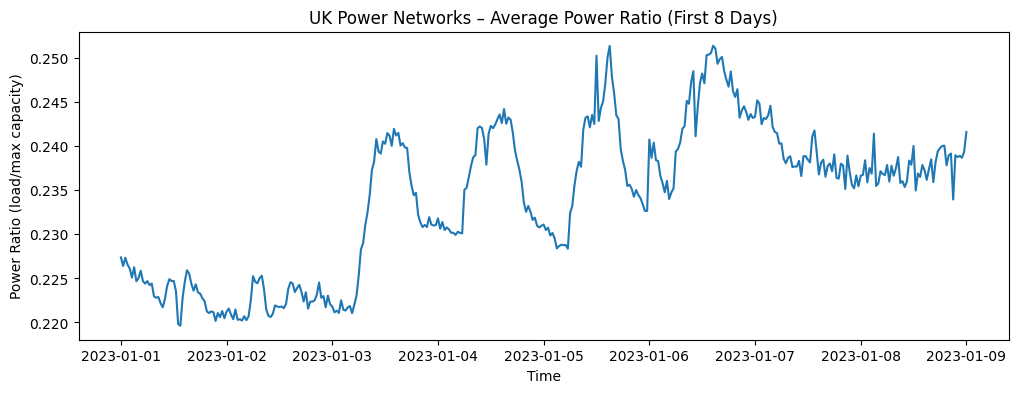

In [6]:
# Load manually uploaded UKPN CSV

# Upload the CSV file
print("Please upload the UKPN CSV file (ukpn-data-centre-demand-profiles.csv)")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_ukpn_raw = pd.read_csv(filename)
print(f"Loaded {len(df_ukpn_raw)} rows.")

# Inspect columns
print("Columns:", df_ukpn_raw.columns.tolist())

# Convert timestamp to datetime
timestamp_col = None
for col in ['utc_timestamp', 'timestamp', 'local_timestamp']:
    if col in df_ukpn_raw.columns:
        timestamp_col = col
        break
if timestamp_col is None:
    raise KeyError("No timestamp column found. Check CSV headers.")
df_ukpn_raw[timestamp_col] = pd.to_datetime(df_ukpn_raw[timestamp_col])

# Identify the utilisation column
util_col = None
for col in ['hh_utilisation_ratio', 'utilisation_ratio', 'load_ratio']:
    if col in df_ukpn_raw.columns:
        util_col = col
        break
if util_col is None:
    raise KeyError("No utilisation column found. Check CSV headers.")

# Create 5-minute bins
df_ukpn_raw['time_bin'] = df_ukpn_raw[timestamp_col].dt.floor('5T')

# Create cluster average
df_ukpn_avg = df_ukpn_raw.groupby('time_bin')[util_col].mean().reset_index()
df_ukpn_avg.rename(columns={util_col: 'power_ratio'}, inplace=True)

# Filter to first 8 days
start_ukpn = df_ukpn_avg['time_bin'].min()
df_ukpn_avg = df_ukpn_avg[df_ukpn_avg['time_bin'] <= start_ukpn + pd.Timedelta(days=8)]
print(f"UKPN cluster average shape (8 days): {df_ukpn_avg.shape}")

# Quick plot
plt.figure(figsize=(12,4))
plt.plot(df_ukpn_avg['time_bin'], df_ukpn_avg['power_ratio'])
plt.title('UK Power Networks – Average Power Ratio (First 8 Days)')
plt.xlabel('Time')
plt.ylabel('Power Ratio (load/max capacity)')
plt.show()

### Compare Synthetic CPU vs Real UKPN Power Pattern

In [ ]:
# Pattern comparison between synthetic UK CPU and real UKPN power

df_synth_5min = df_synthetic.set_index('datetime').resample('5T').mean().reset_index()

# Merge on time
merged = pd.merge(df_synth_5min, df_ukpn_avg, left_on='datetime', right_on='time_bin', how='inner')
print(f"Overlapping time points for comparison: {len(merged)}")

if len(merged) > 0:
    # Plot both on same axes
    fig, ax1 = plt.subplots(figsize=(12,5))

    ax1.plot(merged['datetime'], merged['cpu_utilization'], color='blue', label='Synthetic CPU')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Synthetic CPU (normalised)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(merged['datetime'], merged['power_ratio'], color='red', label='Real UKPN Power')
    ax2.set_ylabel('Real Power Ratio', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.legend(loc='upper right')

    plt.title('Pattern Validation: Synthetic UK CPU vs Real UK Power Demand')
    plt.show()

    # Compute correlation
    corr = merged['cpu_utilization'].corr(merged['power_ratio'])
    print(f"Correlation between synthetic CPU and real power: {corr:.3f}")
else:
    print("No overlapping time periods. Check date ranges.")

## Preprocessing

### Preprocessing Function

In [10]:
# Preprocessing function and application to all datasets
def preprocess_series(df, time_col, value_col, target_name='cpu_norm', freq='5T', fill_method='linear'):
    df = df.copy()
    # Ensure datetime column exists as index
    if time_col in df.columns:
        if df[time_col].dtype in ['int64', 'float64']:
            # Assume seconds from arbitrary start; use a dummy origin
            df['datetime'] = pd.to_datetime(df[time_col], unit='s', origin=pd.Timestamp('2023-01-01'))
        else:
            df['datetime'] = pd.to_datetime(df[time_col])
        df.set_index('datetime', inplace=True)
    else:
        # Assume index is already datetime
        pass
    # Resample to desired frequency
    df = df[[value_col]].resample(freq).mean()
    # Fill missing values
    if fill_method == 'linear':
        df.interpolate(method='linear', inplace=True)
    elif fill_method == 'ffill':
        df.fillna(method='ffill', inplace=True)
    df.fillna(method='bfill', inplace=True)
    # Normalise
    scaler = MinMaxScaler()
    df[target_name] = scaler.fit_transform(df[[value_col]])
    return df[target_name], scaler, df


# Alibaba (single machine)

single_machine = 'm_1932'
df_alibaba_single = df_alibaba[df_alibaba['machine_id'] == single_machine].copy()
cpu_alibaba_norm, scaler_alibaba, df_alibaba_proc = preprocess_series(
    df_alibaba_single, time_col='time_bin', value_col='cpu_util_percent', target_name='cpu_norm'
)
print(f"Alibaba single machine: {len(cpu_alibaba_norm)} bins (expected 2304)")


# Google (cluster average)

cpu_google_norm, scaler_google, df_google_proc = preprocess_series(
    df_google_avg, time_col='time_bin', value_col='cpu_avg', target_name='cpu_norm'
)
print(f"Google cluster average: {len(cpu_google_norm)} bins")


# Azure (cluster average)

df_azure = df_azure[df_azure['time_bin'] <= 8*86400]
cpu_azure_norm, scaler_azure, df_azure_proc = preprocess_series(
    df_azure, time_col='time_bin', value_col='cpu_avg', target_name='cpu_norm'
)
print(f"Azure cluster average: {len(cpu_azure_norm)} bins")


# Apply to Synthetic UK data

cpu_synth_norm, scaler_synth, df_synth_proc = preprocess_series(
    df_synthetic, time_col='datetime', value_col='cpu_utilization', target_name='cpu_norm'
)
print(f"Synthetic UK: {len(cpu_synth_norm)} bins")

# Verify all have same length
print("\nAll series should have 2304 bins (or close):")
print(f"Alibaba: {len(cpu_alibaba_norm)}")
print(f"Google: {len(cpu_google_norm)}")
print(f"Azure: {len(cpu_azure_norm)}")
print(f"Synthetic: {len(cpu_synth_norm)}")

Alibaba single machine: 2293 bins (expected 2304)
Google cluster average: 2304 bins
Azure cluster average: 2305 bins
Synthetic UK: 2304 bins

All series should have 2304 bins (or close):
Alibaba: 2293
Google: 2304
Azure: 2305
Synthetic: 2304


### Feature Engineering (for Random Forest and XGBoost)

In [11]:
# Create lag, rolling statistics, and time features
def create_features(series, target_name='cpu_norm', lags=[1,2,3,6,12], windows=[12,72]):
    df = series.to_frame(name=target_name)
    # Lag features
    for lag in lags:
        df[f'lag_{lag}'] = df[target_name].shift(lag)
    # Rolling statistics
    for win in windows:
        df[f'rolling_mean_{win}'] = df[target_name].rolling(win).mean()
        df[f'rolling_std_{win}'] = df[target_name].rolling(win).std()
    # Time features
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    # Drop rows with NaN from shifts/rolling
    df.dropna(inplace=True)
    y = df[target_name]
    X = df.drop(columns=[target_name])
    return X, y

X_alibaba, y_alibaba = create_features(cpu_alibaba_norm)
print(f"Alibaba feature set shape: {X_alibaba.shape}")
print(f"Sample features:\n{X_alibaba.head()}")

Alibaba feature set shape: (2222, 12)
Sample features:
                        lag_1     lag_2     lag_3     lag_6    lag_12  \
datetime                                                                
2023-01-01 06:50:00  0.444025  0.509360  0.580880  0.678796  0.381888   
2023-01-01 06:55:00  0.495945  0.444025  0.509360  0.450613  0.327794   
2023-01-01 07:00:00  0.415065  0.495945  0.444025  0.533459  0.413086   
2023-01-01 07:05:00  0.437313  0.415065  0.495945  0.580880  0.417401   
2023-01-01 07:10:00  0.389548  0.437313  0.415065  0.509360  0.655383   

                     rolling_mean_12  rolling_std_12  rolling_mean_72  \
datetime                                                                
2023-01-01 06:50:00         0.529642        0.142928         0.237861   
2023-01-01 06:55:00         0.536915        0.133642         0.243175   
2023-01-01 07:00:00         0.538933        0.131771         0.247496   
2023-01-01 07:05:00         0.536612        0.134327         0.25192

In [12]:
# Temporal train/test split
def train_test_split_ts(X, y, train_ratio=0.8):
    split_idx = int(len(X) * train_ratio)
    return (X.iloc[:split_idx], X.iloc[split_idx:],
            y.iloc[:split_idx], y.iloc[split_idx:])

X_train, X_test, y_train, y_test = train_test_split_ts(X_alibaba, y_alibaba)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 1777, Test size: 445


ARIMA - MAE: 0.2915, RMSE: 0.3156


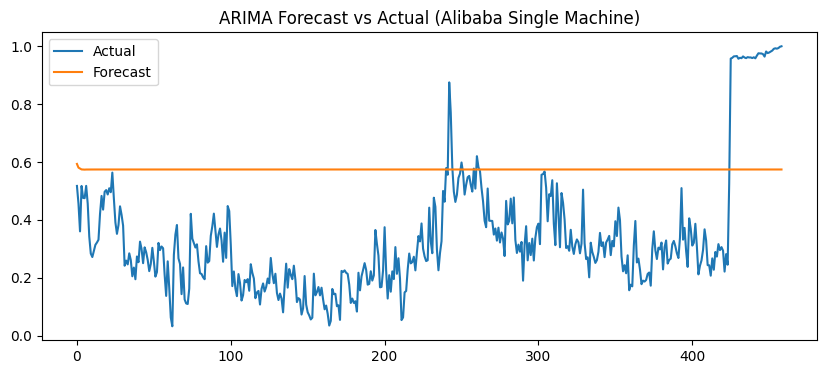

In [13]:
# ARIMA model

train_vals = cpu_alibaba_norm.iloc[:int(0.8*len(cpu_alibaba_norm))].values
test_vals = cpu_alibaba_norm.iloc[int(0.8*len(cpu_alibaba_norm)):].values


model_arima = ARIMA(train_vals, order=(5,1,2))
fitted_arima = model_arima.fit()
forecast_arima = fitted_arima.forecast(steps=len(test_vals))

# Evaluate
mae_arima = mean_absolute_error(test_vals, forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test_vals, forecast_arima))
print(f"ARIMA - MAE: {mae_arima:.4f}, RMSE: {rmse_arima:.4f}")

# Plot
plt.figure(figsize=(10,4))
plt.plot(test_vals, label='Actual')
plt.plot(forecast_arima, label='Forecast')
plt.title('ARIMA Forecast vs Actual (Alibaba Single Machine)')
plt.legend()
plt.show()

Random Forest - MAE: 0.0755, RMSE: 0.1215


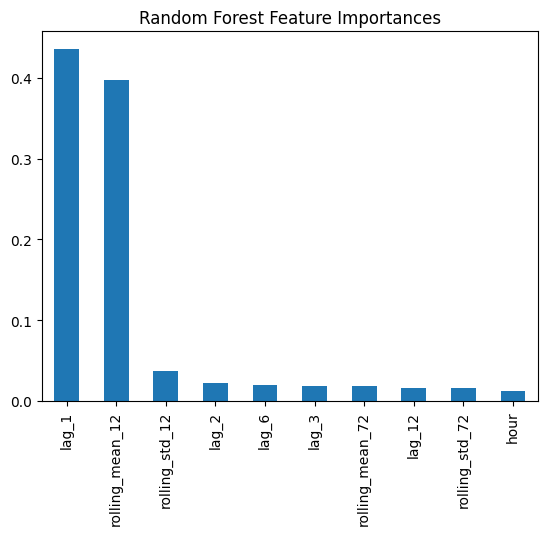

In [14]:
# Random Forest

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"Random Forest - MAE: {mae_rf:.4f}, RMSE: {rmse_rf:.4f}")

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Random Forest Feature Importances')
plt.show()

In [15]:
# XGBoost
xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1)


param_grid = {'n_estimators': [100, 200], 'max_depth': [3, 6], 'learning_rate': [0.01, 0.1]}
tscv = TimeSeriesSplit(n_splits=3)
grid = GridSearchCV(xgb_model, param_grid, cv=tscv, scoring='neg_mean_absolute_error', verbose=1)
grid.fit(X_train, y_train)

best_xgb = grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print(f"XGBoost - MAE: {mae_xgb:.4f}, RMSE: {rmse_xgb:.4f}")
print(f"Best params: {grid.best_params_}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
XGBoost - MAE: 0.0767, RMSE: 0.1285
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


Epoch 1/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0145 - mae: 0.0902 - val_loss: 0.0084 - val_mae: 0.0686
Epoch 2/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0090 - mae: 0.0696 - val_loss: 0.0067 - val_mae: 0.0628
Epoch 3/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0086 - mae: 0.0687 - val_loss: 0.0067 - val_mae: 0.0605
Epoch 4/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0084 - mae: 0.0678 - val_loss: 0.0071 - val_mae: 0.0616
Epoch 5/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0082 - mae: 0.0676 - val_loss: 0.0064 - val_mae: 0.0626
Epoch 6/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0081 - mae: 0.0662 - val_loss: 0.0075 - val_mae: 0.0630
Epoch 7/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0078 - mae: 0.0651 - val_loss: 0.0073 - val_mae: 0.0615
Epoch 8/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0075 - mae: 0.0640 - val_loss: 0.0062 - val_mae: 0.0608
Epoch 9/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0073 - mae:

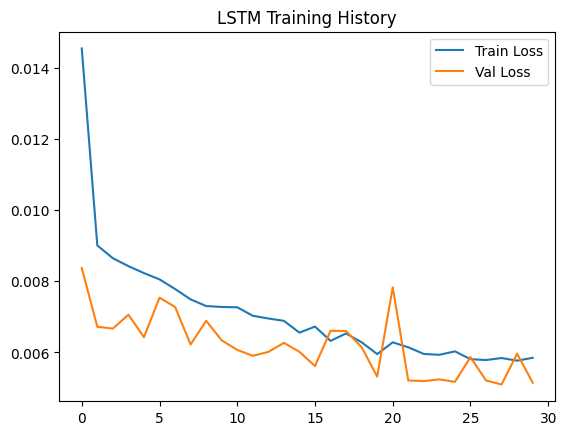

In [16]:
# LSTM

# Prepare sequences for LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_len = 12
values = cpu_alibaba_norm.values.reshape(-1, 1)
X_seq, y_seq = create_sequences(values, seq_len)

# Train/test split
split_idx = int(0.8 * len(X_seq))
X_train_lstm, X_test_lstm = X_seq[:split_idx], X_seq[split_idx:]
y_train_lstm, y_test_lstm = y_seq[:split_idx], y_seq[split_idx:]

# Build model
model_lstm = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_len, 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model_lstm.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=32,
                         validation_split=0.1, callbacks=[early_stop], verbose=1)

# Evaluate
y_pred_lstm = model_lstm.predict(X_test_lstm).flatten()
mae_lstm = mean_absolute_error(y_test_lstm, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))
print(f"LSTM - MAE: {mae_lstm:.4f}, RMSE: {rmse_lstm:.4f}")

# Plot training loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training History')
plt.legend()
plt.show()

In [17]:
# Preprocess memory, disk, network for Alibaba single machine
df_alibaba_single_raw = df_alibaba[df_alibaba['machine_id'] == 'm_1932'].copy()
df_alibaba_single_raw['datetime'] = pd.to_datetime(df_alibaba_single_raw['time_bin'], unit='s', origin=pd.Timestamp('2023-01-01'))
df_alibaba_single_raw.set_index('datetime', inplace=True)
# Resample to 5-min
df_ali_resampled = df_alibaba_single_raw[['cpu_util_percent', 'mem_util_percent', 'disk_io_percent', 'net_in', 'net_out']].resample('5T').mean()
# Interpolate
df_ali_resampled.interpolate(method='linear', inplace=True)
df_ali_resampled.fillna(method='bfill', inplace=True)

# Normalise each column separately
scalers = {}
norm_cols = {}
for col in df_ali_resampled.columns:
    scaler = MinMaxScaler()
    norm_cols[col] = scaler.fit_transform(df_ali_resampled[[col]]).flatten()
    scalers[col] = scaler

# Create Series for each metric
cpu_alibaba_norm = pd.Series(norm_cols['cpu_util_percent'], index=df_ali_resampled.index, name='cpu')
mem_alibaba_norm = pd.Series(norm_cols['mem_util_percent'], index=df_ali_resampled.index, name='mem')
disk_alibaba_norm = pd.Series(norm_cols['disk_io_percent'], index=df_ali_resampled.index, name='disk')
net_alibaba_norm = pd.Series(norm_cols['net_in'], index=df_ali_resampled.index, name='net')

print("Alibaba metrics preprocessed.")

Alibaba metrics preprocessed.


In [18]:
# Model functions
def evaluate_arima(series, train_ratio=0.8):
    train = series.iloc[:int(len(series)*train_ratio)]
    test = series.iloc[int(len(series)*train_ratio):]
    model = ARIMA(train, order=(5,1,2))
    fitted = model.fit()
    forecast = fitted.forecast(steps=len(test))
    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))
    return mae, rmse, forecast, test

def evaluate_rf(X_train, y_train, X_test, y_test):
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    return mae, rmse, pred

def evaluate_xgb(X_train, y_train, X_test, y_test):
    xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    xgb_model.fit(X_train, y_train)
    pred = xgb_model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    return mae, rmse, pred

def evaluate_lstm(series, seq_len=12, train_ratio=0.8):
    # Prepare sequences
    values = series.values.reshape(-1, 1)
    X, y = [], []
    for i in range(len(values) - seq_len):
        X.append(values[i:i+seq_len])
        y.append(values[i+seq_len])
    X = np.array(X)
    y = np.array(y)
    split = int(len(X) * train_ratio)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(seq_len, 1)),
        Dropout(0.2),
        LSTM(50),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1,
                        callbacks=[early_stop], verbose=0)
    pred = model.predict(X_test).flatten()
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    return mae, rmse, pred, y_test

In [19]:
# Create features for each dataset

def create_features_for_series(series, lags=[1,2,3,6,12], windows=[12,72]):
    df = series.to_frame(name='value')
    for lag in lags:
        df[f'lag_{lag}'] = df['value'].shift(lag)
    for win in windows:
        df[f'rolling_mean_{win}'] = df['value'].rolling(win).mean()
        df[f'rolling_std_{win}'] = df['value'].rolling(win).std()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df.dropna(inplace=True)
    X = df.drop(columns=['value'])
    y = df['value']
    return X, y

# For each dataset
X_alibaba, y_alibaba = create_features_for_series(cpu_alibaba_norm)
X_google, y_google = create_features_for_series(cpu_google_norm)
X_azure, y_azure = create_features_for_series(cpu_azure_norm)
X_synth, y_synth = create_features_for_series(cpu_synth_norm)



In [20]:
# Loop over datasets and collect results

results_list = []

# Define the datasets: (name, series) for each
datasets_to_evaluate = [
    ('Alibaba CPU', cpu_alibaba_norm),
    ('Alibaba Memory', mem_alibaba_norm),
    ('Alibaba Disk', disk_alibaba_norm),
    ('Alibaba Net', net_alibaba_norm),
    ('Google', cpu_google_norm),
    ('Azure', cpu_azure_norm),
    ('Synthetic UK', cpu_synth_norm)
]

for name, series in datasets_to_evaluate:
    print(f"\n{'='*50}\nEvaluating {name}...\n{'='*50}")

    # ARIMA
    try:
        train_vals = series.iloc[:int(0.8*len(series))].values
        test_vals = series.iloc[int(0.8*len(series)):].values
        model_arima = ARIMA(train_vals, order=(5,1,2))
        fitted = model_arima.fit()
        forecast = fitted.forecast(steps=len(test_vals))
        mae_arima = mean_absolute_error(test_vals, forecast)
        rmse_arima = np.sqrt(mean_squared_error(test_vals, forecast))
    except Exception as e:
        print(f"ARIMA failed: {e}")
        mae_arima, rmse_arima = None, None

    # andom Forest and XGBoost
    X, y = create_features_for_series(series)
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    mae_rf = mean_absolute_error(y_test, y_pred_rf)
    rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

    # XGBoost
    xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
    rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

    # LSTM
    def create_sequences(data, seq_len=12):
        X, y = [], []
        for i in range(len(data) - seq_len):
            X.append(data[i:i+seq_len])
            y.append(data[i+seq_len])
        return np.array(X), np.array(y)

    values = series.values.reshape(-1, 1)
    seq_len = 12
    X_seq, y_seq = create_sequences(values, seq_len)
    split = int(len(X_seq) * 0.8)
    X_train_lstm, X_test_lstm = X_seq[:split], X_seq[split:]
    y_train_lstm, y_test_lstm = y_seq[:split], y_seq[split:]

    model_lstm = Sequential([
        LSTM(50, return_sequences=True, input_shape=(seq_len, 1)),
        Dropout(0.2),
        LSTM(50),
        Dropout(0.2),
        Dense(1)
    ])
    model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model_lstm.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=32,
                             validation_split=0.1, callbacks=[early_stop], verbose=0)
    y_pred_lstm = model_lstm.predict(X_test_lstm).flatten()
    mae_lstm = mean_absolute_error(y_test_lstm, y_pred_lstm)
    rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))

    # Store results
    results_list.append({
        'Dataset': name,
        'ARIMA_MAE': mae_arima,
        'ARIMA_RMSE': rmse_arima,
        'RF_MAE': mae_rf,
        'RF_RMSE': rmse_rf,
        'XGB_MAE': mae_xgb,
        'XGB_RMSE': rmse_xgb,
        'LSTM_MAE': mae_lstm,
        'LSTM_RMSE': rmse_lstm
    })

# Create DataFrame
df_results = pd.DataFrame(results_list)
print("\n" + "="*80)
print("COMPLETE RESULTS")
print("="*80)
print(df_results.to_string(float_format="%.4f"))

# Save to CSV if desired
df_results.to_csv('model_results.csv', index=False)


Evaluating Alibaba CPU...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Evaluating Alibaba Memory...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Evaluating Alibaba Disk...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Evaluating Alibaba Net...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Evaluating Google...
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step

Evaluating Azure...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Evaluating Synthetic UK...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

COMPLETE RESULTS
          Dataset  ARIMA_MAE  ARIMA_RMSE  RF_MAE  RF_RMSE  XGB_MAE  XGB_RMSE  LSTM_MAE  LSTM_RMSE
0     Alibaba CPU     0.2915      0.3156  0.0755   0.1215   0.0767    0.1285    0.0560     0.0753
1  Alibaba Memory     0.1606      0.2255  0.0546   0.0778   0.0560    0.0795    0.0574     0.0859
2    Alibaba Disk     0.1235      0.1360  0.0449   0.0635   0.0468    0.0660    0.0474     0.0643
3     Alibaba Net     0.0322      0.0420  0.0981   0.1129   0.1035    0.1176    0.0066     0.0072
4          Google     0.1597 

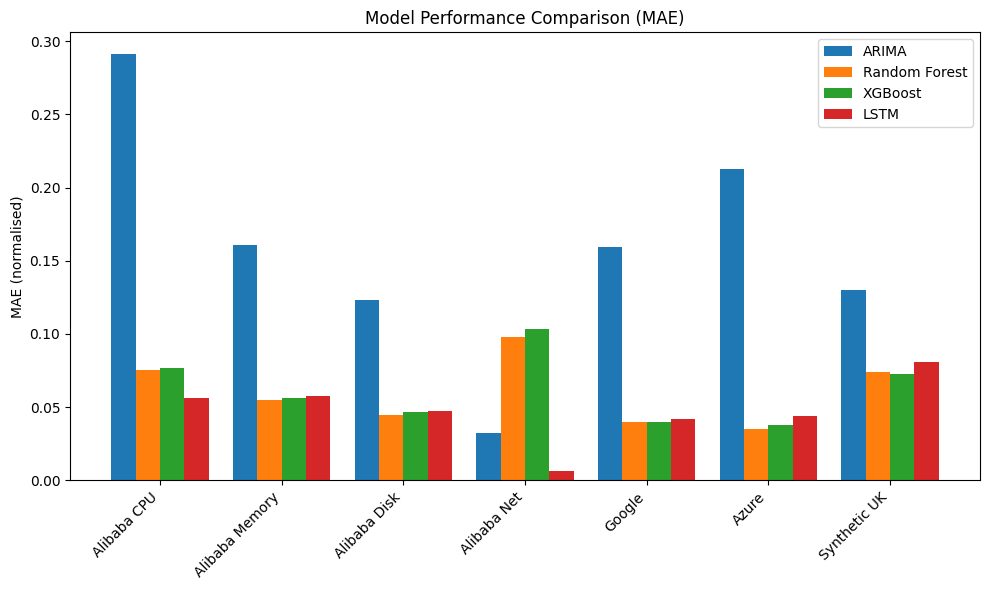

In [22]:
# Bar chart of MAE by model and dataset

datasets = df_results['Dataset'].tolist()
models = ['ARIMA_MAE', 'RF_MAE', 'XGB_MAE', 'LSTM_MAE']
model_names = ['ARIMA', 'Random Forest', 'XGBoost', 'LSTM']

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(datasets))
width = 0.2

for i, (col, name) in enumerate(zip(models, model_names)):
    values = df_results[col].values
    ax.bar(x + i*width, values, width, label=name)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(datasets, rotation=45, ha='right')
ax.set_ylabel('MAE (normalised)')
ax.set_title('Model Performance Comparison (MAE)')
ax.legend()
plt.tight_layout()
plt.savefig('model_mae_comparison.png', dpi=300)
plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


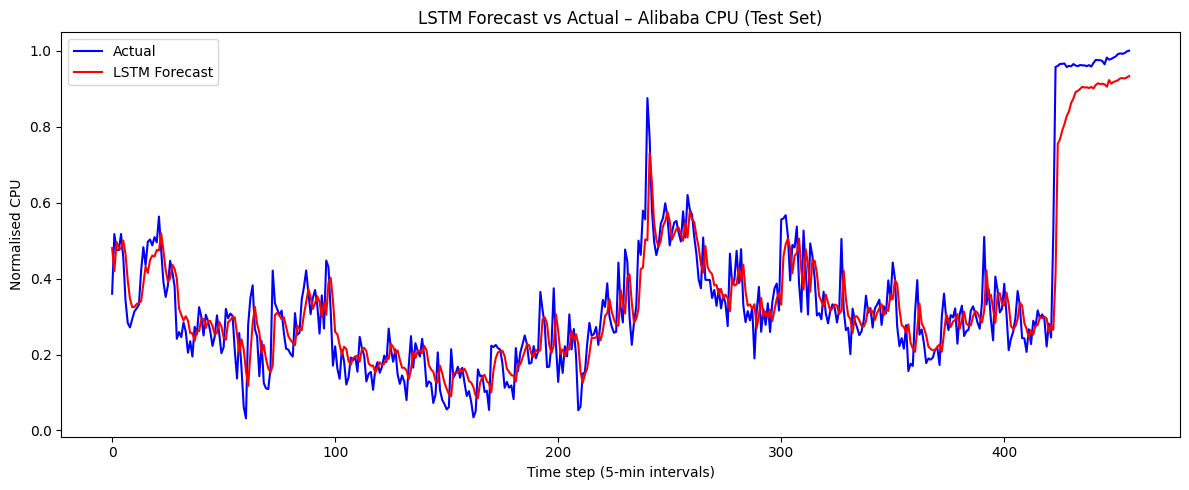

In [23]:
# LSTM predictions on Alibaba CPU test set

# Use Alibaba CPU series
series = cpu_alibaba_norm
values = series.values.reshape(-1, 1)

# Create sequences
def create_sequences(data, seq_len=12):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

seq_len = 12
X_seq, y_seq = create_sequences(values, seq_len)

# Train/test split
split = int(len(X_seq) * 0.8)
X_train_lstm, X_test_lstm = X_seq[:split], X_seq[split:]
y_train_lstm, y_test_lstm = y_seq[:split], y_seq[split:]

# Build LSTM model
model_lstm = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_len, 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train
history = model_lstm.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=32,
                         validation_split=0.1, callbacks=[early_stop], verbose=0)

# Predict on test set
y_pred_lstm = model_lstm.predict(X_test_lstm).flatten()

# Plot
plt.figure(figsize=(12,5))
plt.plot(y_test_lstm, label='Actual', color='blue')
plt.plot(y_pred_lstm, label='LSTM Forecast', color='red')
plt.title('LSTM Forecast vs Actual – Alibaba CPU (Test Set)')
plt.xlabel('Time step (5-min intervals)')
plt.ylabel('Normalised CPU')
plt.legend()
plt.tight_layout()
plt.savefig('alibaba_cpu_lstm_forecast.png', dpi=300)
plt.show()

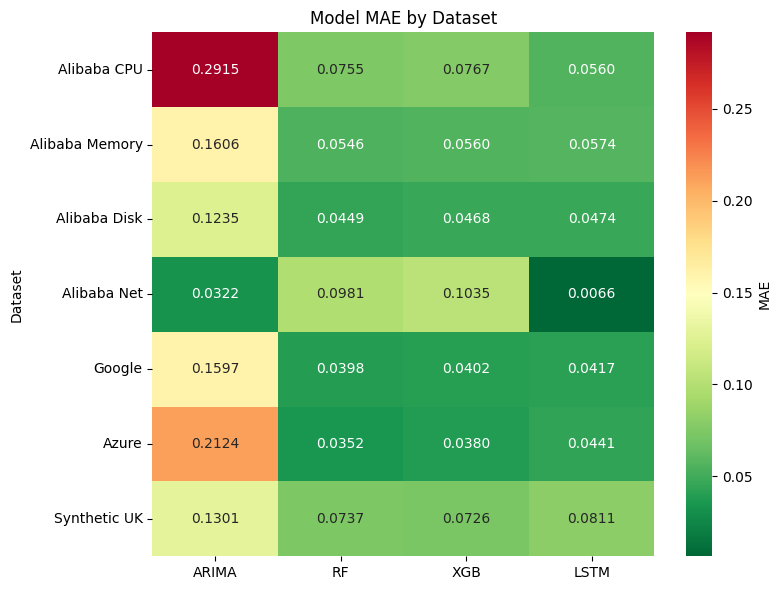

In [24]:
# Heatmap of MAE across models and datasets

# Pivot to matrix format
heat_data = df_results.set_index('Dataset')[['ARIMA_MAE','RF_MAE','XGB_MAE','LSTM_MAE']]
heat_data.columns = ['ARIMA', 'RF', 'XGB', 'LSTM']

plt.figure(figsize=(8,6))
sns.heatmap(heat_data, annot=True, fmt='.4f', cmap='RdYlGn_r', cbar_kws={'label': 'MAE'})
plt.title('Model MAE by Dataset')
plt.tight_layout()
plt.savefig('mae_heatmap.png', dpi=300)
plt.show()

In [25]:
# Interactive Dashboard

output.enable_custom_widget_manager()

# 1. Define helper functions
def create_features_for_series(series, lags=[1,2,3,6,12], windows=[12,72]):
    df = series.to_frame(name='value')
    for lag in lags:
        df[f'lag_{lag}'] = df['value'].shift(lag)
    for win in windows:
        df[f'rolling_mean_{win}'] = df['value'].rolling(win).mean()
        df[f'rolling_std_{win}'] = df['value'].rolling(win).std()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df.dropna(inplace=True)
    X = df.drop(columns=['value'])
    y = df['value']
    return X, y

def train_arima(series, train_ratio=0.8):
    train = series.iloc[:int(len(series)*train_ratio)]
    test = series.iloc[int(len(series)*train_ratio):]
    model = ARIMA(train, order=(5,1,2))
    fitted = model.fit()
    forecast = fitted.forecast(steps=len(test))
    return test.values, forecast.values

def train_rf(series, train_ratio=0.8):
    X, y = create_features_for_series(series)
    split = int(len(X) * train_ratio)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    return y_test.values, pred

def train_xgb(series, train_ratio=0.8):
    X, y = create_features_for_series(series)
    split = int(len(X) * train_ratio)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]
    xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    xgb_model.fit(X_train, y_train)
    pred = xgb_model.predict(X_test)
    return y_test.values, pred

def train_lstm(series, seq_len=12, train_ratio=0.8):
    values = series.values.reshape(-1, 1)
    X_seq, y_seq = [], []
    for i in range(len(values) - seq_len):
        X_seq.append(values[i:i+seq_len])
        y_seq.append(values[i+seq_len])
    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    split = int(len(X_seq) * train_ratio)
    X_train, X_test = X_seq[:split], X_seq[split:]
    y_train, y_test = y_seq[:split], y_seq[split:]
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(seq_len, 1)),
        Dropout(0.2),
        LSTM(50),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    early_stop = EarlyStopping(patience=5, restore_best_weights=True)
    model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1,
              callbacks=[early_stop], verbose=0)
    pred = model.predict(X_test).flatten()
    return y_test.flatten(), pred


# 2. Map dataset names to the actual Series objects
dataset_map = {
    'Alibaba CPU': cpu_alibaba_norm,
    'Alibaba Memory': mem_alibaba_norm,
    'Alibaba Disk': disk_alibaba_norm,
    'Alibaba Net': net_alibaba_norm,
    'Google': cpu_google_norm,
    'Azure': cpu_azure_norm,
    'Synthetic UK': cpu_synth_norm
}

model_map = {
    'ARIMA': train_arima,
    'Random Forest': train_rf,
    'XGBoost': train_xgb,
    'LSTM': train_lstm
}

# 3. Build interactive widgets
dataset_choice = widgets.Dropdown(options=list(dataset_map.keys()), description='Dataset:')
model_choice = widgets.Dropdown(options=list(model_map.keys()), description='Model:')
output = widgets.Output()

def update_plot(dataset_name, model_name):
    with output:
        clear_output(wait=True)
        series = dataset_map[dataset_name]
        train_func = model_map[model_name]
        try:
            y_true, y_pred = train_func(series)
            # Compute metrics
            mae = mean_absolute_error(y_true, y_pred)
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))

            # Plot using Plotly
            fig = go.Figure()
            fig.add_trace(go.Scatter(y=y_true, mode='lines', name='Actual', line=dict(color='blue')))
            fig.add_trace(go.Scatter(y=y_pred, mode='lines', name=f'{model_name} Forecast', line=dict(color='red')))
            fig.update_layout(
                title=f'{model_name} Forecast vs Actual – {dataset_name}<br>MAE={mae:.4f}, RMSE={rmse:.4f}',
                xaxis_title='Time step (5‑min intervals)',
                yaxis_title='Normalised Value',
                legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
            )
            fig.show()
        except Exception as e:
            print(f"Error training {model_name} on {dataset_name}: {e}")

widgets.interactive(update_plot, dataset_name=dataset_choice, model_name=model_choice)
display(dataset_choice, model_choice, output)

Dropdown(description='Dataset:', options=('Alibaba CPU', 'Alibaba Memory', 'Alibaba Disk', 'Alibaba Net', 'Goo…

Dropdown(description='Model:', options=('ARIMA', 'Random Forest', 'XGBoost', 'LSTM'), value='ARIMA')

Output()